In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import random
import librosa
import librosa.display
from matplotlib.patches import Patch

TRAIN_DIR = Path('../data/train')
TARGET_WORDS = {'yes','no','up','down','left','right','on','off','stop','go'}

#later to be done in dataset class
def map_label(word):
    if word == 'silence': return 'silence'
    if word in TARGET_WORDS: return word
    return 'unknown'

samples = []
for word_dir in sorted(TRAIN_DIR.iterdir()):
    for wav in word_dir.glob('*.wav'):
        samples.append({'path': wav, 'word': word_dir.name, 'label': map_label(word_dir.name)})

df = pd.DataFrame(samples)
print(f'Total train files: {len(df):,}')

Total train files: 51,486


#### Class distribution

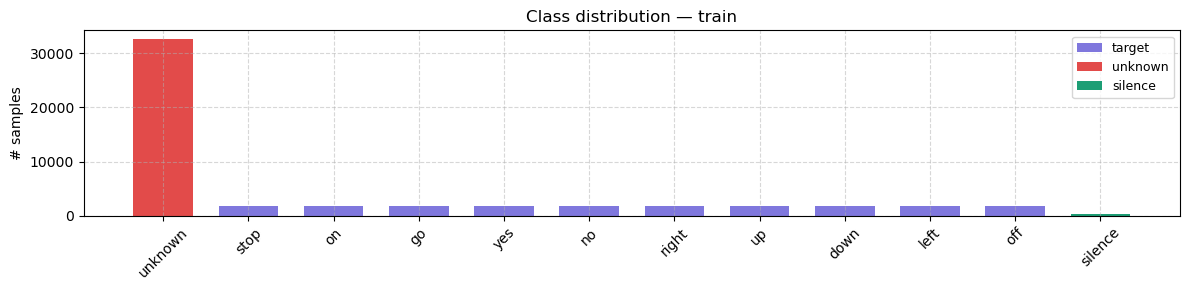

label
unknown    32550
stop        1885
on          1864
go          1861
yes         1860
no          1853
right       1852
up          1843
down        1842
left        1839
off         1839
silence      398


In [ ]:
label_counts = df.groupby('label').size().sort_values(ascending=False)

colors = ['#E24B4A' if l == 'unknown' else '#1D9E75' if l == 'silence' else '#7F77DD' for l in label_counts.index]

fig, ax = plt.subplots(figsize=(12, 3))
ax.bar(label_counts.index, label_counts.values, color=colors, width=0.7)
ax.set_ylabel('# samples')
ax.set_title('Class distribution — train')
ax.tick_params(axis='x', rotation=45)
ax.legend(handles=[
    Patch(facecolor='#7F77DD', label='target'),
    Patch(facecolor='#E24B4A', label='unknown'),
    Patch(facecolor='#1D9E75', label='silence'),
], fontsize=9)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()
print(label_counts.to_string())

#### Audio length distribution

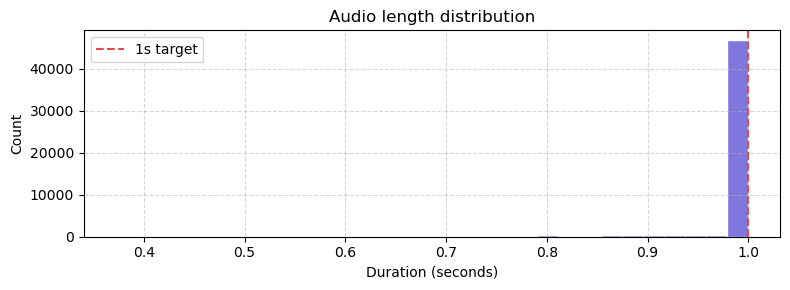

Min: 0.372s   Max: 1.000s   Mean: 0.984s
Shorter than 1s: 5197 / 51486


In [13]:
paths = df['path'].tolist()
durations = [librosa.get_duration(path=str(p)) for p in paths]

fig, ax = plt.subplots(figsize=(8, 3))
ax.hist(durations, bins=30, color='#7F77DD', edgecolor='white')
ax.axvline(1.0, color='#E24B4A', linestyle='--', label='1s target')
ax.set_xlabel('Duration (seconds)')
ax.set_ylabel('Count')
ax.set_title('Audio length distribution')
ax.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

print(f'Min: {min(durations):.3f}s   Max: {max(durations):.3f}s   Mean: {np.mean(durations):.3f}s')
print(f'Shorter than 1s: {sum(d < 0.99 for d in durations)} / {len(durations)}')

#### Waveforms — one example per target class

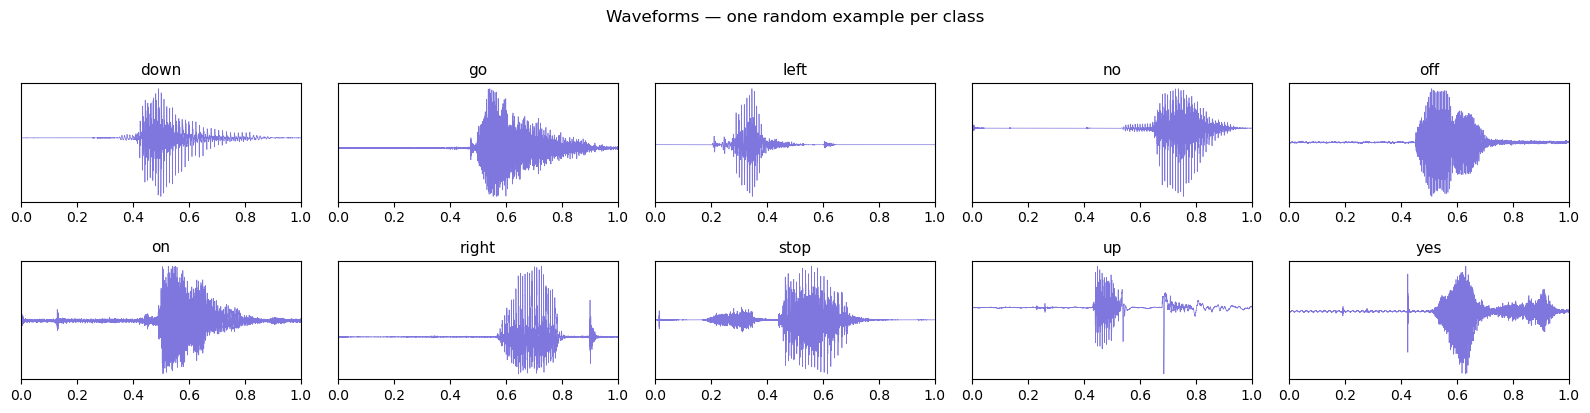

In [ ]:
target_list = sorted(TARGET_WORDS)
fig, axes = plt.subplots(2, 5, figsize=(16, 4))

for ax, word in zip(axes.flat, target_list):
    wav_path = random.choice(list((TRAIN_DIR / word).glob('*.wav')))
    y, sr = librosa.load(str(wav_path), sr=16000)
    y = librosa.util.fix_length(y, size=sr)
    ax.plot(np.linspace(0, 1, len(y)), y, linewidth=0.5, color='#7F77DD')
    ax.set_title(word, fontsize=11)
    ax.set_xlim(0, 1)
    ax.set_yticks([])

plt.suptitle('Waveforms — one random example per class', y=1.02)
plt.tight_layout()
plt.show()

#### MFCCs

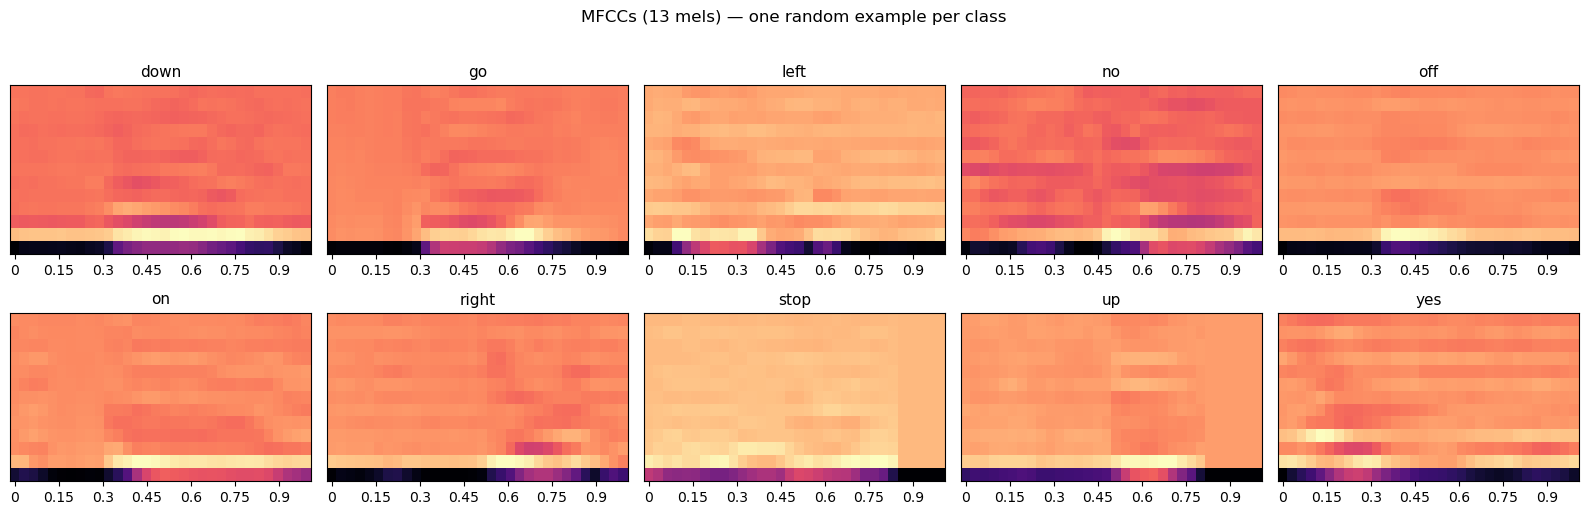

In [18]:
fig, axes = plt.subplots(2, 5, figsize=(16, 5))

for ax, word in zip(axes.flat, target_list):
    wav_path = random.choice(list((TRAIN_DIR / word).glob('*.wav')))
    y, sr = librosa.load(str(wav_path), sr=16000)
    y = librosa.util.fix_length(y, size=sr)
    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13)
    librosa.display.specshow(mfcc, sr=sr, x_axis='time', ax=ax, cmap='magma')   
    ax.set_title(word, fontsize=11)
    ax.set_xlabel('')
    ax.set_ylabel('')

plt.suptitle('MFCCs (13 mels) — one random example per class', y=1.02)
plt.tight_layout()
plt.show()

#### Mel-spectogram

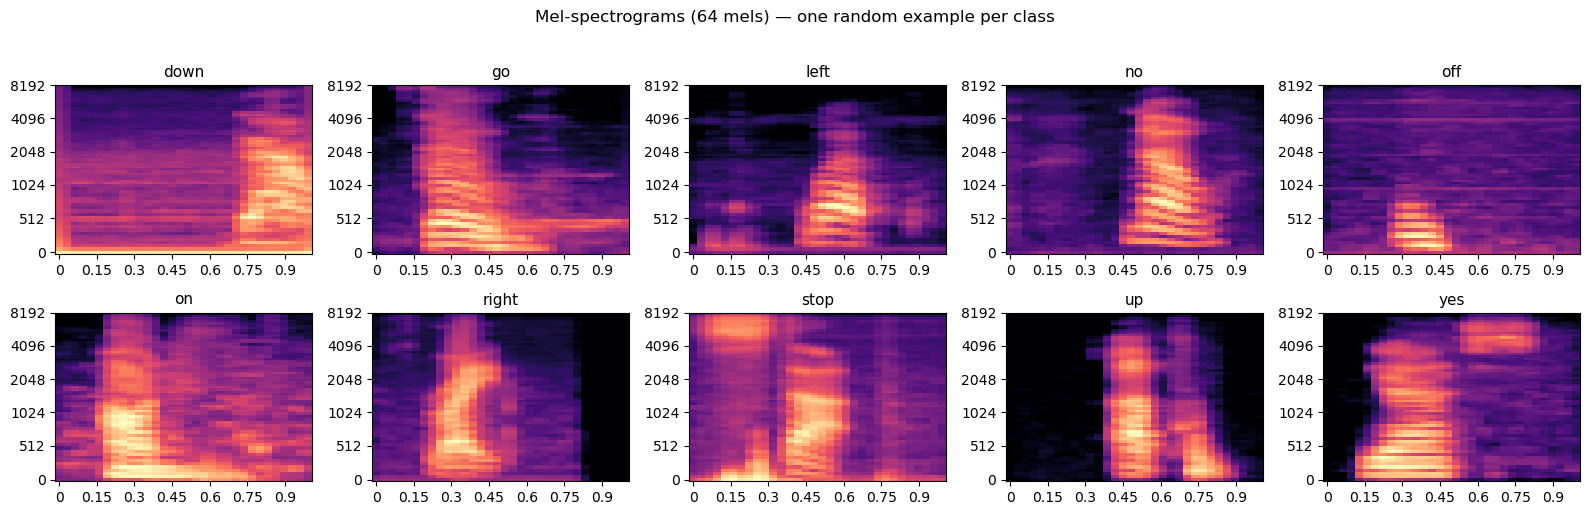

In [8]:
fig, axes = plt.subplots(2, 5, figsize=(16, 5))

for ax, word in zip(axes.flat, target_list):
    wav_path = random.choice(list((TRAIN_DIR / word).glob('*.wav')))
    y, sr = librosa.load(str(wav_path), sr=16000)
    y = librosa.util.fix_length(y, size=sr)
    mel = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=64, fmax=8000)
    mel_db = librosa.power_to_db(mel, ref=np.max)
    librosa.display.specshow(mel_db, sr=sr, x_axis='time', y_axis='mel',
                              fmax=8000, ax=ax, cmap='magma')
    ax.set_title(word, fontsize=11)
    ax.set_xlabel('')
    ax.set_ylabel('')

plt.suptitle('Mel-spectrograms (64 mels) — one random example per class', y=1.02)
plt.tight_layout()
plt.show()

#### Silence vs unknown vs target — comparison of waveforms, MFCC and mel-spectogram

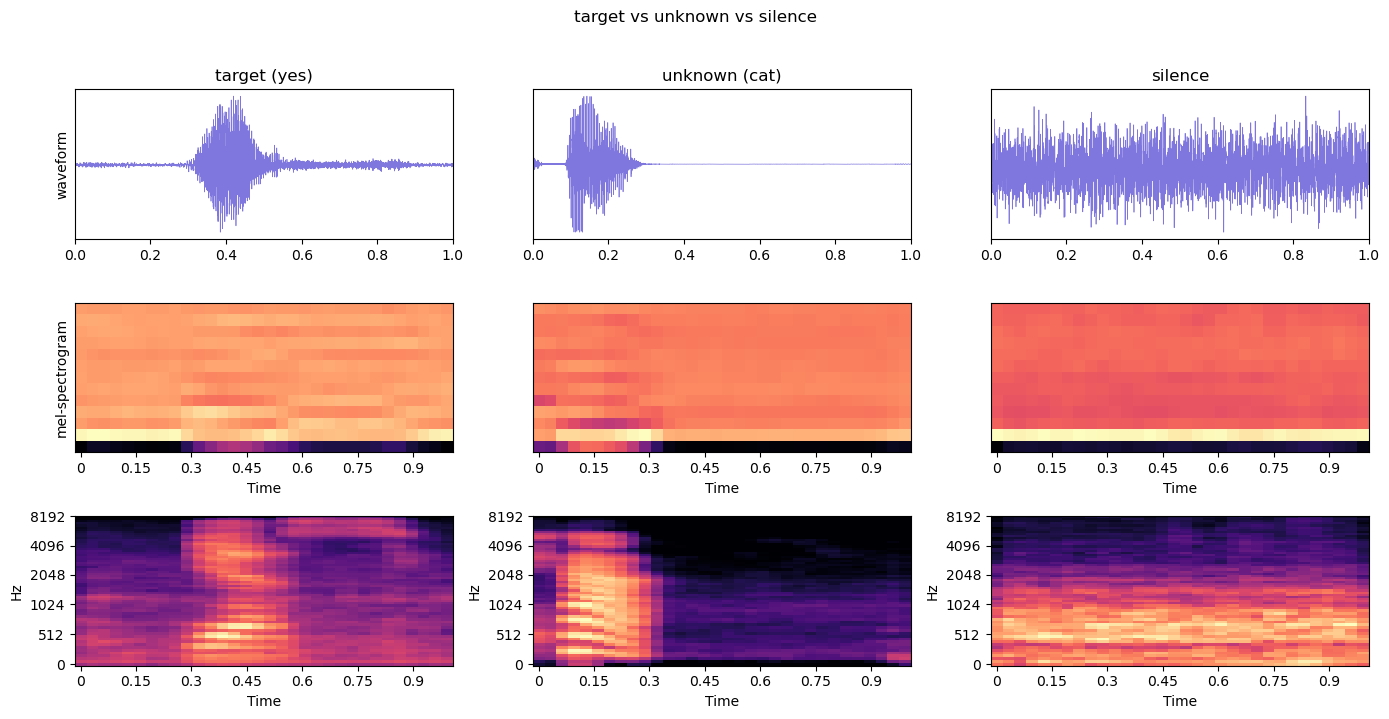

In [17]:
examples = {
    'target (yes)': random.choice(list((TRAIN_DIR / 'yes').glob('*.wav'))),
    'unknown (cat)': random.choice(list((TRAIN_DIR / 'cat').glob('*.wav'))),
    'silence': random.choice(list((TRAIN_DIR / 'silence').glob('*.wav'))),
}

fig, axes = plt.subplots(3, 3, figsize=(14, 7))

for col, (name, path) in enumerate(examples.items()):
    y, sr = librosa.load(str(path), sr=16000)
    y = librosa.util.fix_length(y, size=sr)

    # waveform
    axes[0, col].plot(np.linspace(0, 1, len(y)), y, linewidth=0.5, color='#7F77DD')
    axes[0, col].set_title(name)
    axes[0, col].set_xlim(0, 1)
    axes[0, col].set_yticks([])

    # MFCC
    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13)
    librosa.display.specshow(mfcc, sr=sr, x_axis='time', ax=axes[1, col], cmap='magma')

    # mel spectrogram
    mel = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=64, fmax=8000)
    mel_db = librosa.power_to_db(mel, ref=np.max)
    librosa.display.specshow(mel_db, sr=sr, x_axis='time', y_axis='mel', fmax=8000, ax=axes[2, col], cmap='magma')

axes[0, 0].set_ylabel('waveform')
axes[1, 0].set_ylabel('mel-spectrogram')
plt.suptitle('target vs unknown vs silence', y=1.02)
plt.tight_layout()
plt.show()